# Test LandCover.analyse and ForestType.analyse — single year, multi-year, and range

In [28]:
import sys
sys.path.insert(0, '..')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load config and build the clients

Requires `../config/config.yaml` with your Sentinel Hub credentials:

```yaml
sentinelhub:
  client_id: "your-client-id"
  client_secret: "your-client-secret"
```

(That file is gitignored, so real credentials are safe there. If you'd rather use env vars, leave `sentinelhub: {}` in the file and set `CLMS_SH_CLIENT_ID` / `CLMS_SH_CLIENT_SECRET`.)

In [29]:
from clms_aoi import LandCover, ForestType, CropType

lc = LandCover(config_path="../../config/config.yaml")
ft = ForestType(config_path="../../config/config.yaml")
ct = CropType(config_path="../../config/config.yaml")

## 2. LandCover — single year

Request created successfully
Request created successfully


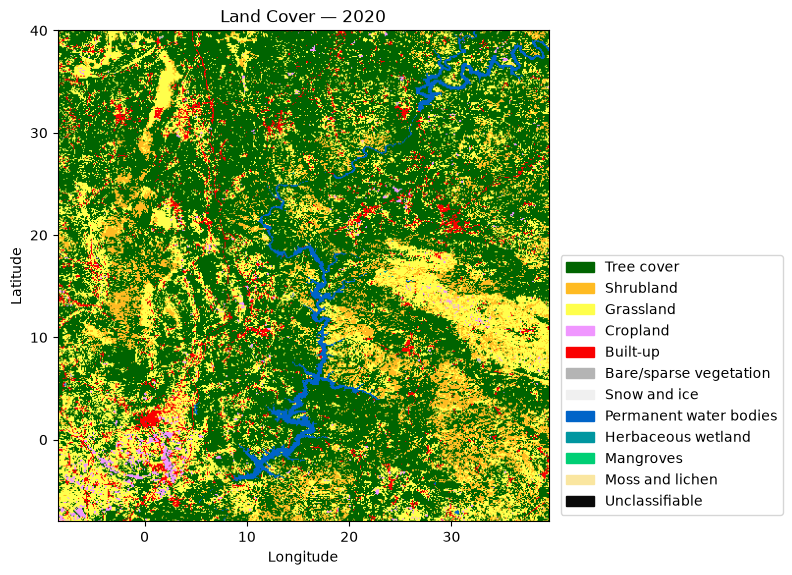

,class,pixel_count,pct,area_ha,year
0,Tree cover,148569,59.43,141379.82,2020
1,Shrubland,22901,9.16,21791.00,2020
2,Grassland,58954,23.58,56095.17,2020
3,Cropland,2996,1.20,2854.72,2020
4,Built-up,16,0.01,23.79,2020
5,Permanent water bodies,128,0.05,118.95,2020
6,Herbaceous wetland,11336,4.53,10776.55,2020
7,Moss and lichen,5100,2.04,4853.02,2020


In [20]:
landcover_aoi_path = "../../tests/data/test_aoi.geojson"

# Note: this BYOC collection currently only has a scene ingested for 2020 —
# other years raise NoDataError (see the multi-year cells below).
result_lc_single = lc.analyse(aoi=landcover_aoi_path, year=2020)

see_result_lc_single = lc.visualize(aoi=landcover_aoi_path, year=2020)
result_lc_single.data

In [5]:
result_lc_single.to_csv("../../tests/data/test_result_landcover_single.csv")
result_lc_single.to_chart(
    "../tests/data/test_result_landcover_single_1.png",
    figsize=(10, 6),
    title="Land Cover Analysis Result for 2020",
)

AnalysisResult(8 rows)

## 3. ForestType — single year

Uses a separate AOI so the forest-type tests don't depend on the land-cover fixture.

Request created successfully
Request created successfully


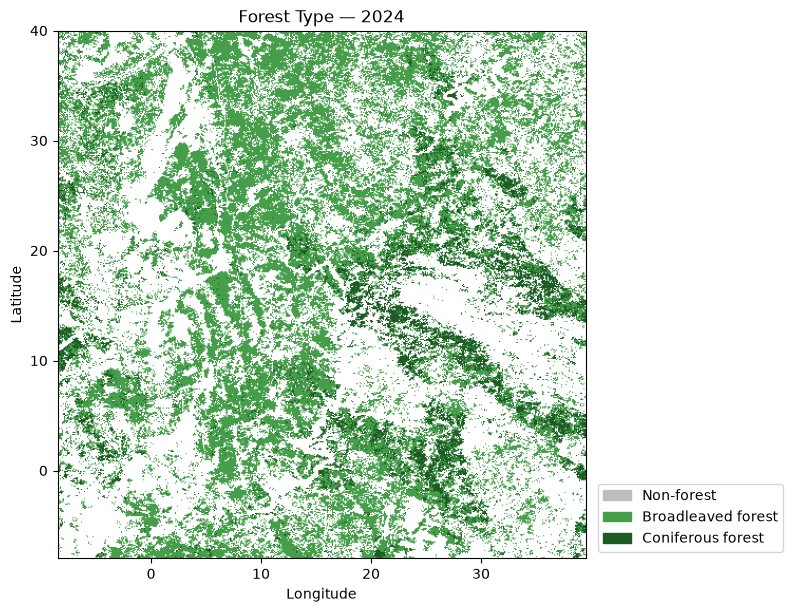

,class,pixel_count,pct,area_ha,year
0,Non-forest,140509,56.20,133695.88,2024
1,Broadleaved forest,92124,36.85,87663.58,2024
2,Coniferous forest,17367,6.95,16533.56,2024


In [40]:
forest_aoi_path = "../../tests/data/test_aoi.geojson"

# Same caveat as land cover: confirm which year is actually ingested in
# the forest-type BYOC collection before trusting a full multi-year run.
result_ft_single = ft.analyse(aoi=forest_aoi_path, year=2024)
result_ft_visual = ft.visualize(aoi=forest_aoi_path, year=2024)
result_ft_single.data

In [22]:
result_ft_single.to_csv("../tests/data/test_result_forest_single.csv")
result_ft_single.to_chart(
    "../tests/data/test_result_forest_single.png",
    figsize=(10, 6),
    title="Forest Type Analysis Result for 2018",
)

AnalysisResult(3 rows)

## 6. ForestType — explicit list of years

In [ ]:
result_ft_multi = ft.analyse(aoi=forest_aoi_path, years=[2018, 2021])
result_ft_multi.data

Request created successfully
Request created successfully


,class,pixel_count,pct,area_ha,year
0,Non-forest,133681,53.47,127201.40,2018
1,Broadleaved forest,94907,37.96,90304.19,2018
2,Coniferous forest,21412,8.56,20363.64,2018
3,Non-forest,138709,55.48,131983.05,2021
4,Broadleaved forest,92964,37.19,88472.41,2021
5,Coniferous forest,18327,7.33,17437.56,2021


## 7. CropType — explicit list of years

In [32]:
result_ct_multi = ct.analyse(aoi=forest_aoi_path, years=[2018, 2021, 2024])
result_ct_multi.data

result_ct_multi.to_chart(
    "../tests/data/test_result_crop_type_multiple.png",
    figsize=(10, 6),
    title="Forest Type Analysis Result for 2021 and 2024",
)

Request created successfully
Request created successfully
Request created successfully


AnalysisResult(43 rows)